In [ ]:
! pip install ppjson numpy pandas matplotlib
! git clone https://github.com/MattechLab/SigInf_2025.git

!pwd
!ls
%cd /content/SigInf_2025/9-et-data-processing/
!ls

In [ ]:
# Derived from:
# https://www.axonlab.org/hcph-sops/data-management/eyetrack-qc
# Load the autoreload extension
%load_ext autoreload
# Set autoreload to update the modules every time before executing a new line of code
%autoreload 2

%matplotlib inline
from pathlib import Path
import json
import ppjson
from importlib import reload  # For debugging purposes

import numpy as np
import pandas as pd

import eyetrackingrun as et

from IPython.display import HTML
from matplotlib import animation
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import copy
# Some functions prepared by Yiwei


# Step 1: Inspecting Eye-Tracking Data

In this step, we’ll begin by parsing the metadata of our eye-tracking data. This will help us understand the structure of the data, including the recording parameters, subject details, and any relevant events or labels. Parsing the metadata provides insight into the conditions and settings during data collection, which is essential for accurate analysis.


In [6]:
# Specify the subject and modality you want to inspect

# You can choose subject_idx from 1 to 4
subject_idx = 2
# You can choose mode 'T1' or 'T2'
T_idx = 1

if T_idx == 1:
    mode = 'T1'
else:
    mode = 'T2'


BIDS_PATH = Path("./data/")  # file within a subdirectory
FILE_NAME = f"sub00{subject_idx}_T{T_idx}"    
    
# session = "001" #can be a string to be defined when required
tsv_name = f"{FILE_NAME}.tsv.gz"

recording_file = BIDS_PATH / tsv_name
print(f'recording_file: {recording_file}')

recording = pd.read_csv(
    recording_file,
#     sep=r"\s+",
    sep="\t",
    na_values="n/a",
)

recording_file: data/sub002_T1.tsv.gz


This command shows the first few rows of our eye-tracking dataset, 
helping us understand the organization, key columns, and the format of the data. 
This step is useful to verify that the data loaded correctly and to identify any initial patterns or anomalies.

In [7]:
recording.head()

,Unnamed: 0,eye1_x_coordinate,eye1_y_coordinate,eye1_pupil_size,eye1_pupil_x_coordinate,eye1_pupil_y_coordinate,eye1_href_x_coordinate,eye1_href_y_coordinate,fast_raw_x_velocity,screen_ppdeg_x_coordinate,screen_ppdeg_y_coordinate,timestamp,eye1_fixation,eye1_saccade,eye1_blink
0,0,414.100006,307.899994,4692.0,-2308.0,-5668.0,139.0,78.0,4.591214e-41,26.5,26.5,3119223,0,0,0
1,1,416.299988,308.399994,4696.0,-2285.0,-5662.0,161.0,83.0,4.591214e-41,26.5,26.5,3119224,0,0,0
2,2,419.700012,309.200012,4703.0,-2250.0,-5653.0,194.0,91.0,4.591214e-41,26.5,26.5,3119225,0,0,0
3,3,423.799988,309.899994,4710.0,-2206.0,-5644.0,235.0,98.0,4.591214e-41,26.5,26.5,3119226,0,0,0
4,4,429.500000,310.100006,4707.0,-2145.0,-5639.0,292.0,99.0,4.591214e-41,26.5,26.5,3119227,0,0,0


In [8]:
print(f'The length of the recording: {len(recording)}')

The length of the recording: 720576


# Step 2: Understanding Metadata

The metadata provides crucial information about the setup and parameters used during eye-tracking data collection. By examining the metadata, we can gain insights into the recording conditions, data quality, and calibration settings.


In [9]:
metadata = json.loads((
    recording_file.parent
    / recording_file.name.replace(".tsv.gz", ".json")
).read_text())

metadata

{'AverageCalibrationError': [0.84],
 'CalibrationCount': 1,
 'CalibrationLog': [[2897461,
   '>>>>>>> CALIBRATION (HV5,P-CR) FOR RIGHT: <<<<<<<<<'],
  [2897462, 'Calibration points:'],
  [2897462, '-27.0, -65.7         0,      0'],
  [2897462, '-25.4, -88.8         0,  -2457'],
  [2897462, '-30.1, -44.3         0,   2457'],
  [2897462, '-66.9, -63.9     -3474,      0'],
  [2897462, '-25.7, -63.1      3474,      0'],
  [2897462, 'eye check box: (L,R,T,B)\n\t  -71   -21   -93   -40'],
  [2897462, 'href cal range: (L,R,T,B)\n\t-5211  5211 -3686  3686'],
  [2897462,
   'Cal coeff:(X=a+bx+cy+dxx+eyy,Y=f+gx+goaly+ixx+jyy)\n   5.882e-05  2108.2  215.51  50.438  2.8157 \n   4.4115e-05 -173.98  92.93 -4.4697 -0.037811'],
  [2897462, 'Prenormalize: offx, offy = -27.036 -65.685'],
  [2897462, 'Gains: cx:2965.506 lx:446.410 rx:5484.733'],
  [2897462, 'Gains: cy:590.000 ty:234.457 by:523.847'],
  [2897462, 'Resolution (upd) at screen center: X=0.1, Y=0.4'],
  [2897462, 'Gain Change Proportion: X: 1

For instance:
- **RecordedEye**: This specifies which eye was tracked. Here, the data corresponds to the right eye.
- **SamplingFrequency**: The sampling rate is 1000 Hz (1 kHz), meaning the data captures 1000 samples per second.
- **CalibrationDetails**: We can see the calibration method used (`HV5`), calibration quality (`GOOD`), and errors.

Understanding these parameters helps us ensure data reliability and assess the quality of eye-tracking measurements before analysis.

In [10]:
# Prepare the time axis based on the sampling frequency
t_axis = (
    recording.timestamp.values - recording.timestamp[0]
) / metadata["SamplingFrequency"]
print(f"The end of the timestamp: {t_axis[-1]}")

The end of the timestamp: 720.575


In [11]:
# Change the naming to make it more readable
recording = recording.rename(
        columns={
            f"eye1_pupil_size": f"pupil_size",
            f"eye1_fixation": f"fixation",
            f"eye1_saccade": f"saccade",
            f"eye1_blink": f"blink",
            f"eye1_x_coordinate": f"x_coordinate", 
            f"eye1_y_coordinate": f"y_coordinate"         
        }
    )

metadata["Columns"] = recording.columns.tolist()

In [12]:
metadata["Columns"]

['Unnamed: 0',
 'x_coordinate',
 'y_coordinate',
 'pupil_size',
 'eye1_pupil_x_coordinate',
 'eye1_pupil_y_coordinate',
 'eye1_href_x_coordinate',
 'eye1_href_y_coordinate',
 'fast_raw_x_velocity',
 'screen_ppdeg_x_coordinate',
 'screen_ppdeg_y_coordinate',
 'timestamp',
 'fixation',
 'saccade',
 'blink']

# Step 3: Inspecting Signals, Event Masks and Correlation
In this step we first visualize all the signals in the recordings to examine the overall shapes (trend, variability, or periodicity) and the scale of its values (range and units).

Besides, eye-tracking data includes event masks, which label segments of the data corresponding to specific events such as blinks, saccades, or fixations. These masks are typically binary arrays or categorical labels indicating the presence of a specific event at each timestamp.

In [13]:
# Please visualize the signals you are interested in:
# your codes
# ---for example---
# check_all = True
# if check_all:
#     fig,axes = plt.subplots(6, 1, figsize=(10, 36), sharex=False)

#      # Plot x coordinate
#     axes[0].plot(t_axis, recording["x_coordinate"].values, label='X Coordinate', color='blue')
#     axes[0].set_title("X coordinate")
#     axes[0].legend()
#     axes[0].set_xlabel("time [s]")

#     plt.ylabel(" ");
    

We can check the pupil area

In [14]:
# Please check the pupil area along x axis
# your codes

Check the eye events:

 - Blink
    
- Saccade
    
- Fixation


We want to first check the masks of each event and want to inspect the correlation with the signals we checked above.

Check blinking


In [ ]:
# Check blinking
check_blink = True
if check_blink:
    fig = plt.figure(figsize=(16, 2))
    plt.plot(
        t_axis,
        recording["blink"].values,
    )
    plt.title("Blink Event")
    plt.xlabel("time [s]")
    plt.ylabel("eyes closed");

    fig = plt.figure(figsize=(16, 2))
    plt.plot(
        t_axis,
        recording["blink"].values * 10000,
    )
    plt.xlabel("time [s]")
    plt.ylabel("eyes closed")
    plt.title("Zoom in - Blink Event")
    plt.xlim((100, 150))

Check saccading

In [ ]:
# Your turn :) 

Check fixation

In [ ]:
# Your turn :) 

Plot the event mask overlapped with x, y coordinates respectively to find the correlation.

In [ ]:
# Your turn :) 

Did you find the correlation between x/y coordinates, pupil area and saccade or fixation events?


# Step 4: Data Cleaning

- Extract the signals we need 

- Eliminate the blinking and non-fixation area of ET data.
- Design some criteria for preserving the useful data


## 4.1: Extract the signals we need

In this exercise, we are focusing on a subset of the eye-tracking (ET) data. Specifically, we will process the first portion of the ET data, which corresponds to the duration of the sequence `T1_LIBRE`.


We will extract the first portion of the data with a length matching `T1_LIBRE`.
Inspect the extracted subset to understand its structure and characteristics, such as gaze coordinates and event markers.

In [16]:
# Here is the given inforation: time duration (in sec) according to the prior information.

if  subject_idx == 1:
    T1_LIBRE = 374.558
elif subject_idx == 2:
    T1_LIBRE = 374.380
elif subject_idx == 3:
    T1_LIBRE = 334.237
else:
    T1_LIBRE = 374.565



print(f"The length of T1_LIBRE Subject{subject_idx} should be: {T1_LIBRE}.")
print('This is the prior information which is fixed and provided here.')



The length of T1_LIBRE Subject2 should be: 374.38.
This is the prior information which is fixed and provided here.


In [17]:
# Size of screen
size = (
    metadata["ScreenAOIDefinition"][1][1],
    metadata["ScreenAOIDefinition"][1][3],
)

# For easier processing the entire recording and only the coordinate
# We stored the (x,y) coordinate in the coor_data 
# And stored the entire recording in the coor_recording
coor_data = recording[["x_coordinate", "y_coordinate"]]
print(f"Extract X Y coordinates from recording: {len(coor_data)}")

coor_recording = recording

    
coor_data.head()
coor_recording.head()

Extract X Y coordinates from recording: 720576


,Unnamed: 0,x_coordinate,y_coordinate,pupil_size,eye1_pupil_x_coordinate,eye1_pupil_y_coordinate,eye1_href_x_coordinate,eye1_href_y_coordinate,fast_raw_x_velocity,screen_ppdeg_x_coordinate,screen_ppdeg_y_coordinate,timestamp,fixation,saccade,blink
0,0,414.100006,307.899994,4692.0,-2308.0,-5668.0,139.0,78.0,4.591214e-41,26.5,26.5,3119223,0,0,0
1,1,416.299988,308.399994,4696.0,-2285.0,-5662.0,161.0,83.0,4.591214e-41,26.5,26.5,3119224,0,0,0
2,2,419.700012,309.200012,4703.0,-2250.0,-5653.0,194.0,91.0,4.591214e-41,26.5,26.5,3119225,0,0,0
3,3,423.799988,309.899994,4710.0,-2206.0,-5644.0,235.0,98.0,4.591214e-41,26.5,26.5,3119226,0,0,0
4,4,429.500000,310.100006,4707.0,-2145.0,-5639.0,292.0,99.0,4.591214e-41,26.5,26.5,3119227,0,0,0


mode: T1
set start margin as 0
374380


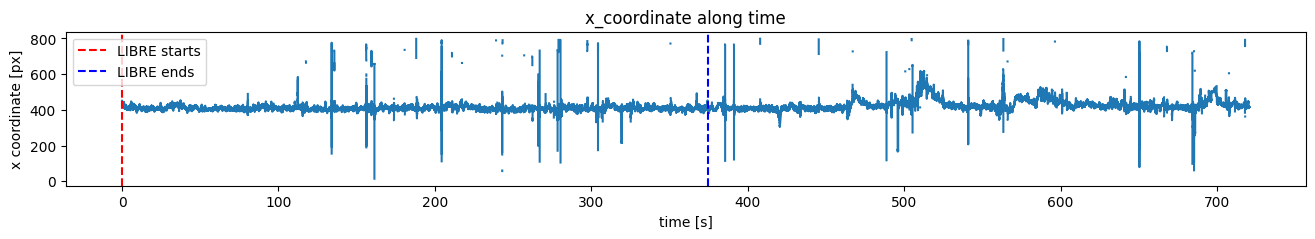

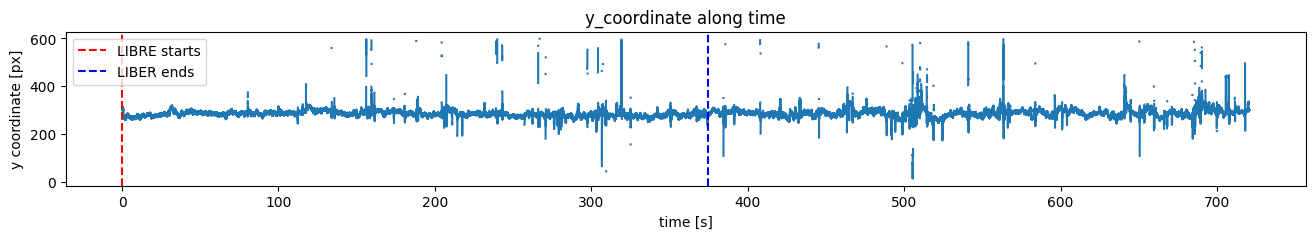

In [18]:
# start_margin determines where to begin extracting the useful portion of the eye-tracking (ET) data.
# In our case, it is set as 0, it is prior information and we fix it here.

start_margin = int(0.0*metadata['SamplingFrequency']) 

print(f'mode: {mode}')
print(f"set start margin as {start_margin}")


T1_LIBRE_sample = T1_LIBRE*metadata['SamplingFrequency']



t_axis_xy = (
    coor_data.index 
) / metadata["SamplingFrequency"]

# x coordinate
fig = plt.figure(figsize=(16, 2))

plt.plot(
    t_axis_xy,
    coor_data["x_coordinate"].values,
)


plt.axvline(x=start_margin/metadata["SamplingFrequency"], color='r', linestyle='--', label='LIBRE starts')
plt.axvline(x=(T1_LIBRE_sample+start_margin)/metadata["SamplingFrequency"], color='b', linestyle='--', label='LIBRE ends')

    
plt.title("x_coordinate along time")
plt.xlabel("time [s]")
plt.ylabel("x coordinate [px]")
plt.legend()

# y coordinate
fig = plt.figure(figsize=(16, 2))

plt.plot(
    t_axis_xy,
    coor_data["y_coordinate"].values,
)

plt.axvline(x=start_margin/metadata["SamplingFrequency"], color='r', linestyle='--', label='LIBRE starts')
plt.axvline(x=(T1_LIBRE_sample+start_margin)/ metadata["SamplingFrequency"], color='b', linestyle='--', label='LIBER ends')


    
plt.title("y_coordinate along time")
plt.xlabel("time [s]")
plt.ylabel("y coordinate [px]")
plt.legend()

coor_data_LIBRE = coor_data[start_margin:int(T1_LIBRE_sample)] 
coor_recording_LIBRE = coor_recording[start_margin:int(T1_LIBRE_sample)] 

coor_data_LIBRE_raw = copy.deepcopy(coor_data_LIBRE)
print(len(coor_data_LIBRE))


## 4.2 Eliminating blinking

Based on the blink mask explored earlier, we now process the data to handle timestamps where blinks occurred. During a blink, gaze data is unreliable or missing, so we mark these periods by assigning NaN (Not a Number) to the gaze coordinates.

Note: instead of filtering them out, please assign nan to the invalid elements to preserve the time information

In [ ]:
use_eliminate_blink = False #After you finish the code in this block, please activate the flag to "True"

def eliminate_blink(coor_data, coor_recording, seq_name):
    # Your turn: finish your code of this line below
    len_coord_blink = ???
    
    print(f'The data will be eliminated: {len_coord_blink}')
    coor_data.loc[coor_recording.blink > 0,  ['x_coordinate', 'y_coordinate']] = np.nan
    coor_recording.loc[coor_recording.blink > 0,  ['x_coordinate', 'y_coordinate']] = np.nan

    return coor_data, coor_recording


if use_eliminate_blink:
    coor_data_LIBRE,  coor_recording_LIBRE = eliminate_blink(coor_data_LIBRE, coor_recording_LIBRE, 'LIBRE')

plot_heatmap = True
if plot_heatmap:
    import plot
    plot.plot_heatmap_coordinate(coor_data_LIBRE, density=False, screen_size=size, 
                                 title='LIBRE: The gaze from the beginning to the end')


## 4.3 Preserving fixation

Similarly, we will preserve the timestamps where fixation events are detected.

In [ ]:
#======After you finish the code in this block, please activate the flag to "True"========
use_preserve_fixation = False 

def preserve_fixation(coor_data, coor_recording, seq_name):
    # =======Your turn :)===============
    len_coord_blink =???
    # =================================
    print(f'The data will be eliminated: {len_coord_blink}')
    # Following the method above, how to filter the coor_data and coor_recording?
    # =======Your turn :) ============
    coor_data = ???
    coor_recording = ???
    # =================================
    return coor_data, coor_recording


if use_preserve_fixation:
    coor_data_LIBRE,  coor_recording_LIBRE = preserve_fixation(coor_data_LIBRE, coor_recording_LIBRE, 'LIBRE')

plot_heatmap = False
if plot_heatmap:
    import plot
    plot.plot_heatmap_coordinate(coor_data_LIBRE, density=False, screen_size=size, 
                                 title='LIBRE: The gaze from the beginning to the end')
 

## 4.4 Plot the gazing dots

To visualize the gaze points before/after the data cleaning

In [ ]:
from matplotlib.font_manager import FontProperties
title_font = FontProperties(family='DejaVu Serif', size=20, weight='bold')
axis_font = FontProperties(family='DejaVu Serif', size=20)
# ============================================================
# Example data (replace with your actual data)
X_coord = coor_data_LIBRE_raw['x_coordinate']
Y_coord = coor_data_LIBRE_raw['y_coordinate']
fig, ax= plt.subplots(figsize=(8, 6))
# Plot the data, flipping X coordinates and using dots as markers
plt.scatter(X_coord, Y_coord, s=50, c='#00468b', alpha=0.1, edgecolors='#00468b', linewidth=0.5)
plt.xlim((0, 800))
plt.ylim((0, 600))
# Set plot title
plt.title('LIBRE: Before filtering', fontproperties=title_font)

for label in plt.gca().get_xticklabels():
    label.set_fontproperties(axis_font)

for label in plt.gca().get_yticklabels():
    label.set_fontproperties(axis_font)
# Reverse the direction of the Y-axis
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

# ============================================================
# Example data (replace with your actual data)
X_coord = coor_data_LIBRE['x_coordinate']
Y_coord = coor_data_LIBRE['y_coordinate']
fig, ax= plt.subplots(figsize=(8, 6))
# Plot the data, flipping X coordinates and using dots as markers
plt.scatter(X_coord, Y_coord, s=50, c='#00468b', alpha=0.1, edgecolors='#00468b', linewidth=0.5)
plt.xlim((0, 800))
plt.ylim((0, 600))
# Set plot title
plt.title('LIBRE: After Filtering', fontproperties=title_font)

for label in plt.gca().get_xticklabels():
    label.set_fontproperties(axis_font)

for label in plt.gca().get_yticklabels():
    label.set_fontproperties(axis_font)
# Reverse the direction of the Y-axis
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
# ============================================================



## 4.5 Analyzing Gaze Point Distribution Before and After Filtering

After filtering out blink-related timestamps by assigning NaN to gaze coordinates, it's important to inspect how this operation has affected the distribution of gaze points along each dimension (e.g., x_coordinate and y_coordinate).

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the figure
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot KDE for eye1_x_coordinate
sns.kdeplot(coor_data_LIBRE_raw['x_coordinate'].dropna(), ax=axes[0], color='blue', fill=True, label='raw_x_coordinate')
sns.kdeplot(coor_data_LIBRE['x_coordinate'].dropna(), ax=axes[0], color='orange', fill=True, label='filtered_x_coordinate')
axes[0].set_title("X Coordinate: Raw vs. Filtered")
axes[0].set_xlabel("X Coordinate (px)")
axes[0].set_ylabel("Density")
axes[0].set_xlim((250,550))
axes[0].legend()

# Plot KDE for y coordinate
sns.kdeplot(coor_data_LIBRE_raw["y_coordinate"].dropna(), ax=axes[1], color='teal', fill=True, label='raw_y_coordinate')
sns.kdeplot(coor_data_LIBRE["y_coordinate"].dropna(), ax=axes[1], color='coral', fill=True, label='filtered_y_coordinate')
axes[1].set_title("Y Coordinate: Raw vs. Filtered")
axes[1].set_xlabel("Y Coordinate (px)")
axes[1].set_ylabel("Density")
axes[1].set_xlim((250,350))
axes[1].legend()

# Add a common title
fig.suptitle("Distribution of Eye-Tracking Data Along X Dimension", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Step 5: Calculate the mask, statistics 

You can calculate the mask based on your user case. 

In the following step, I will present my method to generate the mask according to the project I introduced in the course.

In [ ]:
# Here are some functions already implemented according to the project.
from mask_gen import cal_mask, plot_x_y_coord, filter_XY_coord

In [ ]:
def cal_stats(coor_data):
    stats_dict = {}
    X_coord = coor_data["x_coordinate"].values
    Y_coord = coor_data["y_coordinate"].values

    # Please finish the following codes:
    # =================================================
    # stats_dict['x_mean'] =  
    # stats_dict['x_median'] =       # Median, ignoring NaNs
    # stats_dict['x_std'] =        # Standard deviation
    # stats_dict['x_min'] =    # Minimum value
    # stats_dict['x_max'] =      # Maximum value
    # # Calculate 25th, 50th (median), and 75th percentiles while ignoring NaN values
    # stats_dict['x_q25'] =    # 25th percentile
    # stats_dict['x_q75'] =    # 75th percentile

    # stats_dict['y_mean'] =  
    # stats_dict['y_median'] =      # Median, ignoring NaNs
    # stats_dict['y_std'] =         # Standard deviation
    # stats_dict['y_min'] =       # Minimum value
    # stats_dict['y_max'] =        # Maximum value
    # stats_dict['y_q25'] =    # 25th percentile
    # stats_dict['y_q75'] =    # 75th percentile

    return stats_dict



In [ ]:
coor_data_LIBRE_1 = copy.deepcopy(coor_data_LIBRE)
stats_dict = cal_stats(coor_data_LIBRE_1)
print(stats_dict)

# You can play with the upper and lower boundary to filter the data as you need
stand_x_upper=stats_dict['x_q75']-stats_dict['x_median']
stand_x_lower=stats_dict['x_q25']-stats_dict['x_median']
stand_y_upper=stats_dict['y_q75']-stats_dict['y_median']
stand_y_lower=stats_dict['y_q25']-stats_dict['y_median']
print(f'stand_x_upper-{stand_x_upper} stand_x_lower-{stand_x_lower} stand_y_upper-{stand_y_upper} stand_y_lower-{stand_y_lower}')

Disp_dict_LIBRE = cal_mask(coor_data_LIBRE_1, stand_x_upper, stand_x_lower, 
                           stand_y_upper, stand_y_lower)
plot_x_y_coord(Disp_dict_LIBRE, metadata, duration=None, start_sample=0, seq_name='LIBRE')
filtered_coor_data_LIBRE, Preserve_mask, Discard_mask = filter_XY_coord(coor_data_LIBRE_1, Disp_dict_LIBRE, None)

In [ ]:
coor_data_LIBRE_1 = copy.deepcopy(coor_data_LIBRE)
stats_dict = cal_stats(coor_data_LIBRE_1)
print(stats_dict)

# You can play with the upper and lower boundary to filter the data as you need
stand_x_upper=40
stand_x_lower=-40
stand_y_upper=40
stand_y_lower=-40
print(f'stand_x_upper-{stand_x_upper} stand_x_lower-{stand_x_lower} stand_y_upper-{stand_y_upper} stand_y_lower-{stand_y_lower}')

Disp_dict_LIBRE = cal_mask(coor_data_LIBRE_1, stand_x_upper, stand_x_lower, 
                           stand_y_upper, stand_y_lower)
plot_x_y_coord(Disp_dict_LIBRE, metadata, duration=None, start_sample=0, seq_name='LIBRE')
filtered_coor_data_LIBRE, Preserve_mask, Discard_mask = filter_XY_coord(coor_data_LIBRE_1, Disp_dict_LIBRE, None)

In [ ]:
# You can play with the upper and lower boundary to filter the data as you need
stand_x_upper=40
stand_x_lower=-40
stand_y_upper=40
stand_y_lower=-40
print(f'stand_x_upper-{stand_x_upper} stand_x_lower-{stand_x_lower} stand_y_upper-{stand_y_upper} stand_y_lower-{stand_y_lower}')

Disp_dict_LIBRE = cal_mask(coor_data_LIBRE_1, stand_x_upper, stand_x_lower, 
                           stand_y_upper, stand_y_lower)
plot_x_y_coord(Disp_dict_LIBRE, metadata, duration=None, start_sample=0, seq_name='LIBRE')
filtered_coor_data_LIBRE, Preserve_mask, Discard_mask = filter_XY_coord(coor_data_LIBRE_1, Disp_dict_LIBRE, None)

In [ ]:
def visualization_func(fig_title, filtered_coor_data_LIBRE):
    from matplotlib.font_manager import FontProperties
    title_font = FontProperties(family='DejaVu Serif', size=20, weight='bold')
    axis_font = FontProperties(family='DejaVu Serif', size=20)
    
    fig, ax= plt.subplots(figsize=(8, 6))
    plt.title(fig_title, fontproperties=title_font)
#     -----------------------------------------------------------------------
#     # Plot the data, flipping X coordinates and using dots as markers
#     X_coord = coor_data_STANDARD['x_coordinate']
#     Y_coord = coor_data_STANDARD['y_coordinate']
#     plt.plot(X_coord, Y_coord, '.', color='#ADD8E6', markersize=15, label='Standard')
#     -----------------------------------------------------------------------
    coor_data_LIBRE_vis = copy.deepcopy(coor_data_LIBRE)
    X_coord_1 = coor_data_LIBRE_raw['x_coordinate']
    Y_coord_1 = coor_data_LIBRE_raw['y_coordinate']

    # plt.plot(X_coord_1, Y_coord_1, '.', color='#728FCE', markersize=15, label='LIBRE w.o. binning')
    plt.scatter(X_coord_1, Y_coord_1, s=50, c='#728FCE', alpha=0.1, edgecolors='#728FCE', linewidth=0.5)
    
#     -----------------------------------------------------------------------
    X_coord = filtered_coor_data_LIBRE['x_coordinate']
    Y_coord = filtered_coor_data_LIBRE['y_coordinate']
    print(F"if same {X_coord_1 == X_coord}")
    # plt.plot(X_coord, Y_coord, '.', color='#f4d03f', markersize=15, label='LIBRE binning')
    plt.scatter(X_coord, Y_coord, s=50, c='#f4d03f', alpha=0.1, edgecolors='#f4d03f', linewidth=0.5)  # Larger points
#     ----------------------------------------------------------------------------------------------
    # plt.legend(prop={'family': 'DejaVu Serif', 'size': 10})
    
    plt.tick_params(axis='x', labelsize=14)
    plt.tick_params(axis='y', labelsize=14)
    plt.xlim((0, 800))
    plt.ylim((0, 600))
    # Set plot title
#     plt.title(fig_title, fontproperties=title_font)
    for label in plt.gca().get_xticklabels():
        label.set_fontproperties(axis_font)

    for label in plt.gca().get_yticklabels():
        label.set_fontproperties(axis_font)
    # Reverse the direction of the Y-axis
    plt.gca().invert_yaxis()
    plt.gca().invert_xaxis()

    
# Visualization of filtered coor data LIBRE
visualization_func(fig_title='Before vs. After Filtering', 
                   filtered_coor_data_LIBRE=filtered_coor_data_LIBRE)



# Step 6: Investigate the statistics of eye movement events across different subjects
Eye movement events such as blinks, saccades, and fixations provide valuable information about gaze behavior and data quality. By analyzing these events across different subjects, we can assess the consistency and reliability of the recorded data.


## 6.1 Statistics calculation

In [ ]:
# Specify the subject and modality you want to inspect

T_idx = 1
recording_list = []
for subject_idx in range(1,5):
    print(f'Load recording for subject {subject_idx}...')
    if T_idx == 1:
        mode = 'T1'
    else:
        mode = 'T2'
    
    
    BIDS_PATH = Path("./data/")  # file within a subdirectory
    FILE_NAME = f"sub00{subject_idx}_T{T_idx}"    
        
    
    tsv_name = f"{FILE_NAME}.tsv.gz"
    
    recording_file = BIDS_PATH / tsv_name
    print(f'recording_file: {recording_file}')
    
    recording = pd.read_csv(
        recording_file,
    #     sep=r"\s+",
        sep="\t",
        na_values="n/a",
    )
    
    # Duration setting according to the MRI sequence info
    if  subject_idx == 1:
        T1_LIBRE = 374.558
        T2_LIBRE = 650.185
    elif subject_idx == 2:
        T1_LIBRE = 374.380
        T2_LIBRE = 650.185
    elif subject_idx == 3:
        T1_LIBRE = 334.237
        T2_LIBRE = 650.1925 
    else:
        T1_LIBRE = 374.565
        T2_LIBRE = 650.1875

    if T_idx == 1:
        print(f"The length of T1_LIBRE Subject{subject_idx} should be: {T1_LIBRE}")
    else:
        print(f"The length of T2_LIBRE Subject{subject_idx} should be: {T2_LIBRE}")

    coor_recording = recording
    start_margin = int(0.0)
    if mode == 'T1':
        print(f'mode: {mode}')
        T1_LIBRE_sample = T1_LIBRE*metadata['SamplingFrequency']
   
    else:
        print(f'mode: {mode}')
        T2_LIBRE_sample = T2_LIBRE*metadata['SamplingFrequency']
        
        
    if mode == 'T1':
        coor_recording_LIBRE = coor_recording[start_margin:int(T1_LIBRE_sample)]   
    else:
        coor_recording_LIBRE = coor_recording[start_margin:int(T2_LIBRE_sample)] 
    coor_recording_LIBRE = coor_recording_LIBRE.rename(columns={'eye1_saccade': 'saccade'})
    coor_recording_LIBRE = coor_recording_LIBRE.rename(columns={'eye1_fixation': 'fixation'})
    coor_recording_LIBRE = coor_recording_LIBRE.rename(columns={'eye1_blink': 'blink'})
    recording_list.append(coor_recording_LIBRE)

In [ ]:
len(recording_list)

In [ ]:
# Identify start and end indices of each event
def identify_start_end_event(df, events):
    event_dict = {}
    for event in events:
        event_change = event+'_change'
        
        event_starts = df.index[df[event_change] == 1].tolist()
        event_ends = df.index[df[event_change] == -1].tolist()
        
        # If the last row is part of a event, add it as an end
        if df[event].iloc[-1] == 1:
            event_ends.append(df.index[-1])
        
        # Calculate number of events
        num_events = len(event_starts)
        
        # Calculate duration for each event
        event_durations = []
        for start, end in zip(event_starts, event_ends):
            # Duration in milliseconds or based on the timestamp difference
            duration = end - start + 1  # If in milliseconds
            # If you have a timestamp column (e.g., in ms), you could calculate it as:
            # duration = df['timestamp'].iloc[end] - df['timestamp'].iloc[start]
            event_durations.append(duration)
        
        # Display results
        num_event_str = 'num_'+event
        event_dict[num_event_str] = num_events
        event_duration_str = event+'_durations'
        event_dict[event_duration_str] = event_durations

    return event_dict
  


In [ ]:
events = ['saccade', 'fixation', 'blink']
subject_event_dict = []
for idx in range(4):
    df = copy.deepcopy(recording_list[idx])
    # Detect the start and end of each saccade
    df['saccade_shift'] = df['saccade'].shift(1, fill_value=0)
    df['saccade_change'] = df['saccade'] - df['saccade_shift']
    
    # Detect the start and end of each fixation
    df['fixation_shift'] = df['fixation'].shift(1, fill_value=0)
    df['fixation_change'] = df['fixation'] - df['fixation_shift']
    
    # Detect the start and end of each blink
    df['blink_shift'] = df['blink'].shift(1, fill_value=0)
    df['blink_change'] = df['blink'] - df['blink_shift']

    event_dict = identify_start_end_event(df, events)
    subject_event_dict.append(event_dict)

In [ ]:
def cal_event_stat(event_duration):
    
    event_stat_dict={}
    event_stat_dict['mean_duration'] = np.mean(event_duration)
    event_stat_dict['median_duration'] = np.median(event_duration)
    event_stat_dict['std_duration'] = np.std(event_duration)
    event_stat_dict['min_duration'] = np.min(event_duration)
    event_stat_dict['max_duration'] = np.max(event_duration)
    event_stat_dict['total_duration'] = sum(event_duration)
    event_stat_dict['times'] = len(event_duration)
    
    return event_stat_dict
    
def voilinplot(subject_event_dict, event,color='skyblue'):
    sub_num = len(subject_event_dict)
    event_duration_list=[]
    for idx in range(sub_num):
        event_durations_str = f'{event}_durations'
        event_duration_list.append(subject_event_dict[idx][event_durations_str])
        
    df = pd.DataFrame({
        'Duration': [duration for sublist in event_duration_list for duration in sublist],
        'Subject': [f'Subject {i+1}' for i, sublist in enumerate(event_duration_list) for _ in sublist]
    })
   
    plt.figure(figsize=(6, 5))
    sns.violinplot(data=df, x='Subject', y='Duration', color=color)
    plt.title(f"Violin Plot of {event} Durations Across Subjects")
    plt.ylabel("Duration (ms)")
    plt.xlabel("Subject")
    plt.show()

In [ ]:
subject_blink_stat = []
subject_saccade_stat = []
subject_fixation_stat = []
for idx in range(4):
    event_dict = subject_event_dict[idx]
    
    blink_stat = cal_event_stat(event_dict['blink_durations'])
    subject_blink_stat.append(blink_stat)
    
    saccade_stat = cal_event_stat(event_dict['saccade_durations'])
    subject_saccade_stat.append(saccade_stat)
    
    fixation_stat = cal_event_stat(event_dict['fixation_durations'])
    subject_fixation_stat.append(fixation_stat)

In [ ]:
subject_fixation_stat

A Violin Plot is a Useful Tool for Visualizing Event Statistics.

A violin plot combines the features of a box plot and a density plot, making it particularly useful for visualizing the distribution of data. It provides a comprehensive view of both the summary statistics and the underlying data distribution, which is highly beneficial when analyzing eye movement event statistics across different subjects.

In [ ]:
voilinplot(subject_event_dict, event='blink', color='skyblue')
voilinplot(subject_event_dict, event='saccade',color='coral')
voilinplot(subject_event_dict, event='fixation',color='teal')

## 6.2 Statistics Test

Statistical tests, such as the Mann-Whitney U Test, t-Test, and Kolmogorov-Smirnov Test are used to compare statistics to determine whether differences between groups or conditions are significant or due to random variation. Without statistical tests, comparisons might rely on subjective observations or visual inspection, which are prone to bias. Statistical tests provide quantifiable and reproducible evidence to support conclusions.

- The Mann-Whitney U test is a non-parametric statistical test used to determine whether there is a significant difference between the distributions of two independent samples. 
It is particularly useful when comparing groups where the data may not meet the assumptions required by parametric tests like the t-test.

- T-test requires normally distributed data and equal variances, which may not hold true for eye movement statistics. Violating these assumptions could lead to misleading results.

- Kolmogorov-Smirnov Test compares entire distributions but lacks the sensitivity of the Mann-Whitney U test for detecting location shifts (differences in medians).


Eye-tracking event statistics (e.g., blink counts, fixation durations) may not follow normal distributions due to inter-subject variability or artifacts. The Mann-Whitney U test allows robust comparison of these statistics between groups or conditions without requiring strict assumptions about the data.


In [ ]:
def mann_whitney_u_stats(subject_event_dict, event):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    from scipy.stats import mannwhitneyu
    sub_num = len(subject_event_dict)
    event_duration_list=[]
    for idx in range(sub_num):
        event_durations_str = f'{event}_durations'
        event_duration_list.append(subject_event_dict[idx][event_durations_str])
        
    # Prepare data for Seaborn
    df = pd.DataFrame({
        'Duration': [duration for sublist in event_duration_list for duration in sublist],
        'Subject': [f'subjects {i+1}' for i, sublist in enumerate(event_duration_list) for _ in sublist]
    })

    print(f"Pairwise Mann-Whitney U test results for {event} durations:")
    for i in range(sub_num):
        for j in range(i + 1, sub_num):
            stat, p_value = mannwhitneyu(event_duration_list[i], event_duration_list[j], alternative='two-sided')
            print(f"Comparison between {f'subjects {i+1}'} and {f'subjects {j+1}'}: U = {stat}, p = {p_value:.4f}")




In [ ]:
mann_whitney_u_stats(subject_event_dict,'saccade')

# 7 Your turn :)

In the previous part, we have seen the example of eye tracking data during T1w (T_idx = 1). And we went through the entire procedure for one subject of:

- Visualization of signals
- Data cleaning
- Data filtering
- Generate masks

Besides, we also inspected the eye movement events across 4 subjects, and compared the statistics.

Could you make your own analysis on the data during T2w? (T_idx = 2)

    

In [ ]:

# Note that:
#     Time Duration (ms) according to the MRI sequence info
# You need to crop the raw data from 0 to T2_LIBRE*SamplingFrequency

if  subject_idx == 1:
    T1_LIBRE = 374.558
    T2_LIBRE = 650.185
elif subject_idx == 2:
    T1_LIBRE = 374.380
    T2_LIBRE = 650.185
elif subject_idx == 3:
    T1_LIBRE = 334.237
    T2_LIBRE = 650.1925 
else:
    T1_LIBRE = 374.565
    T2_LIBRE = 650.1875 